# 04 — Evaluation

Metrics below are recomputed by loading `models/` and repeating the stratified 80/20 split (`random_state=42`) from `src/evaluate.py`. They are printed next to `models/metadata.json`. A gap above 0.02 means this split is not the exact split that produced the shipped file; the joblib files are still left unchanged.

The confusion matrix, residual story, and permutation-importance figure from the original run are in `reports/figures/`.


In [1]:
import json
from pathlib import Path
from src.evaluate import compare, score_saved_models

actual = score_saved_models(Path("data/StudentPerformanceFactors.csv"), Path("models"))
expected = json.loads(Path("models/metadata.json").read_text(encoding="utf-8"))["test_metrics"]
print(json.dumps(actual, indent=2))
gaps = compare(actual, expected)
print("Within 0.02." if not gaps else "Gaps:\n" + "\n".join(gaps))


{
  "regression_all_rows": {
    "MAE": 0.7614685519420368,
    "RMSE": 1.8928388583768059,
    "R2": 0.736274693734934
  },
  "regression_typical_rows": {
    "RMSE": 1.016865269040254,
    "R2": 0.9102213758280585
  },
  "classification": {
    "Accuracy": 0.7829046898638427,
    "Precision": 0.780071763905569,
    "Recall": 0.8169963133194468,
    "F1_macro": 0.7770501513846598,
    "ROC_AUC": 0.9266375179586273,
    "High_Risk_Recall": 0.7535211267605634
  },
  "score_range_coverage": {
    "all_rows": 0.8948562783661119,
    "typical_rows": 0.8996197718631179
  },
  "clustering_silhouette": 0.1278930189765971,
  "n_outliers": 7
}
Gaps:
regression_all_rows.MAE: recomputed 0.761469, metadata 0.857879, difference 0.096411
regression_all_rows.RMSE: recomputed 1.892839, metadata 2.531539, difference 0.638701
regression_all_rows.R2: recomputed 0.736275, metadata 0.626467, difference 0.109808
regression_typical_rows.RMSE: recomputed 1.016865, metadata 0.813664, difference 0.203201
regres

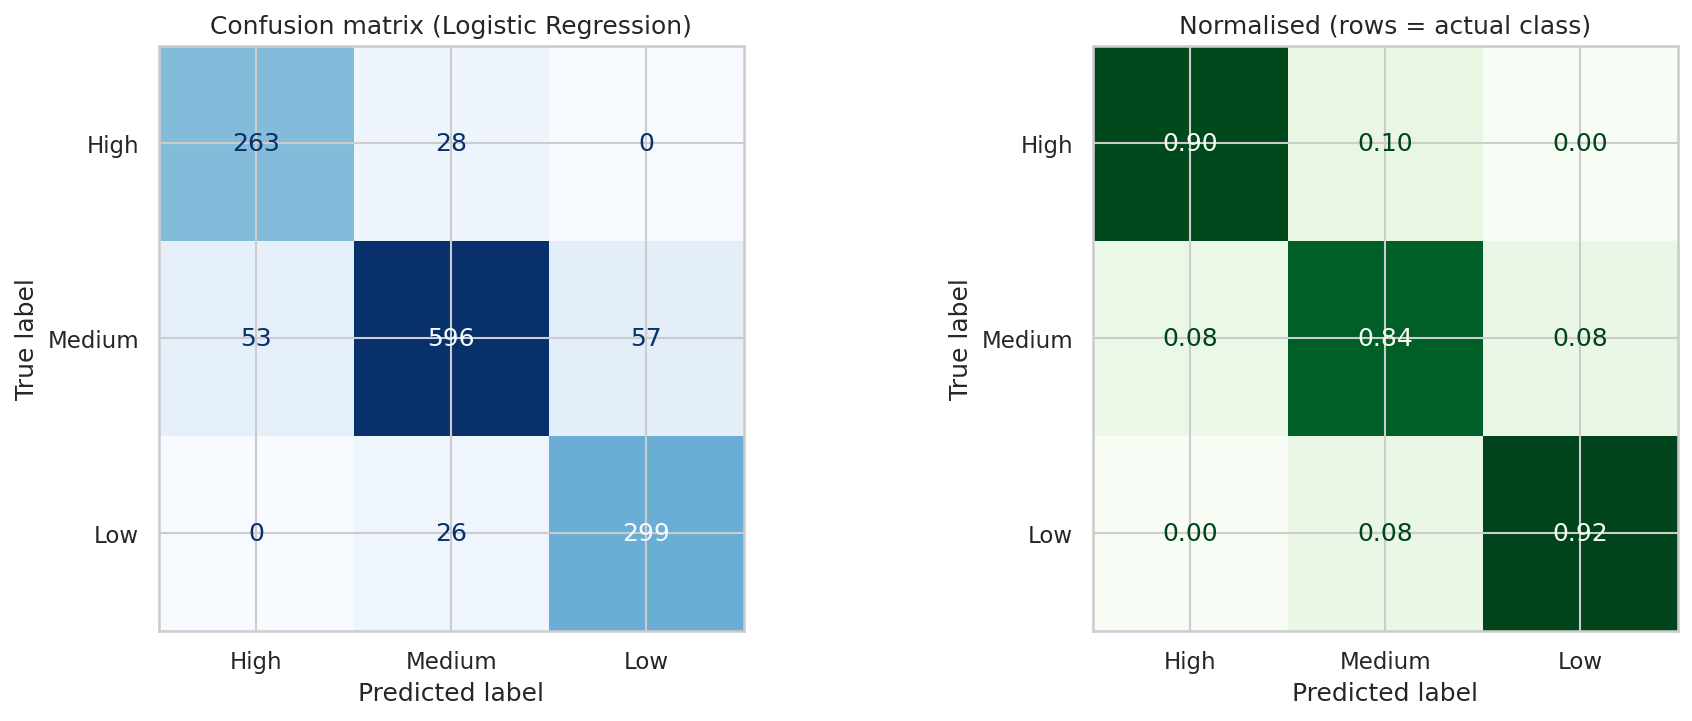

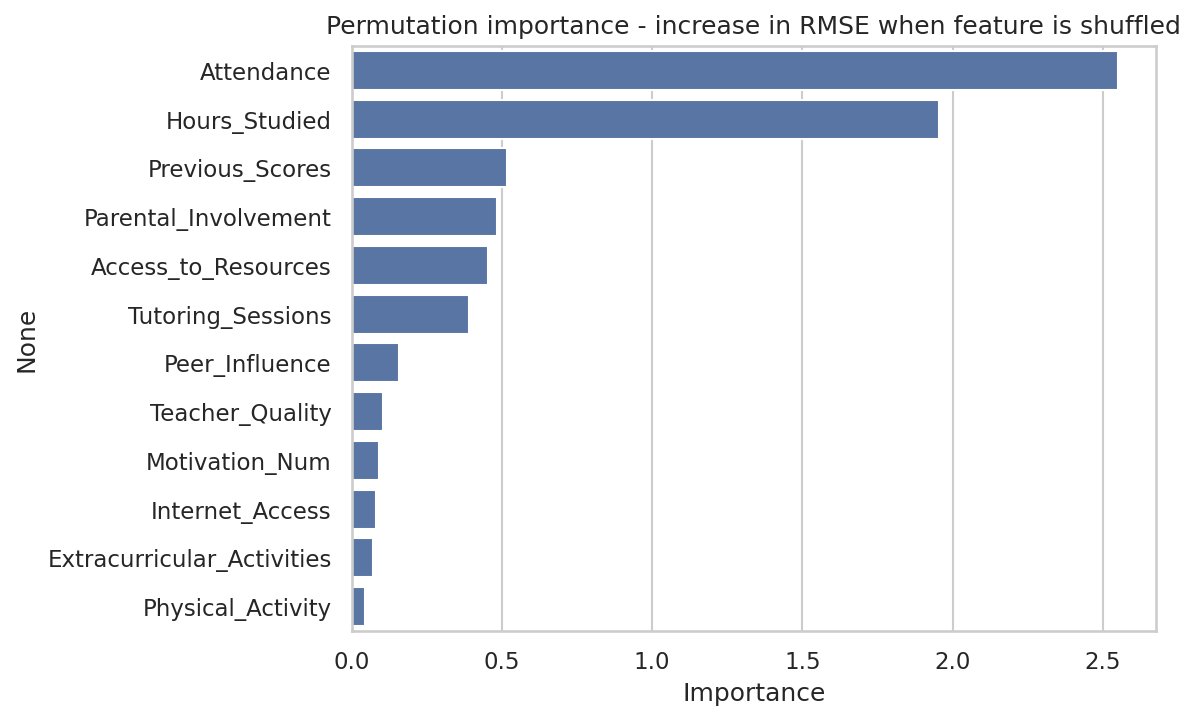

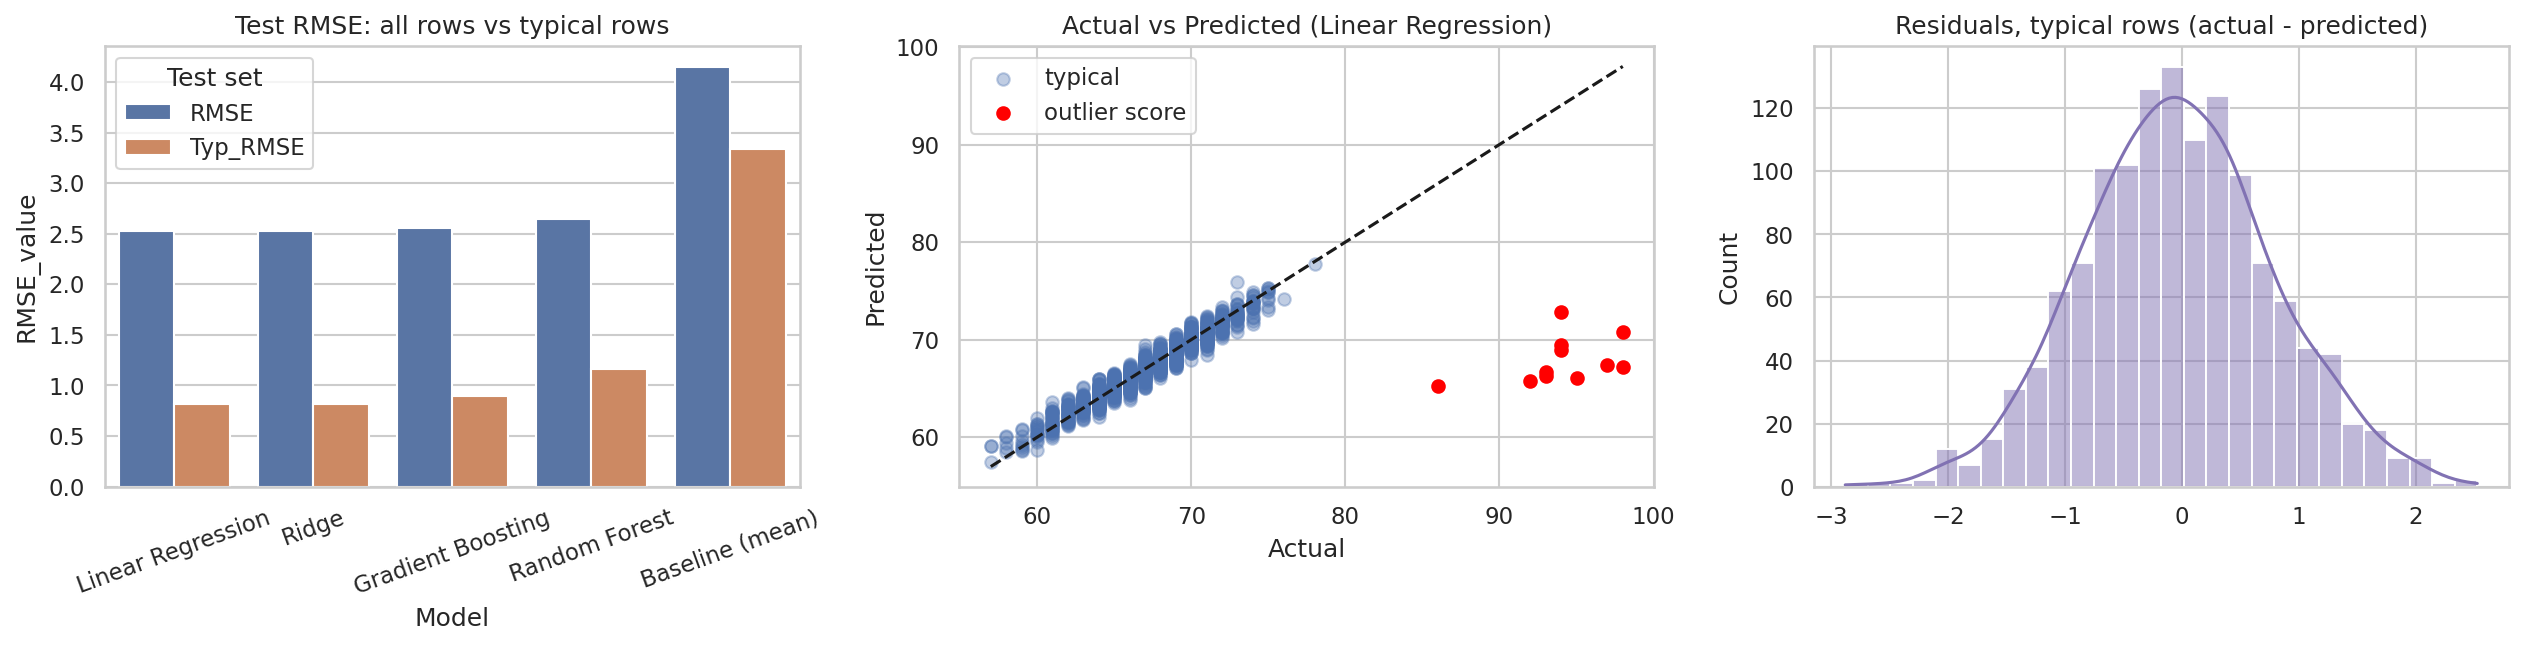

In [2]:
from IPython.display import Image, display
from pathlib import Path
for name in ["classification_confusion.png", "explainability_importance.png", "regression_results.png"]:
    display(Image(filename=str(Path("reports/figures") / name)))
